# TCI - SVD truncation

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
#from scipy.sparse.linalg import eigsh, expm_multiply, expm

In [56]:
import importlib

import sys
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Correlation_function')
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Chebyshev")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/TCI")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Correlation_function")


import ED_Cs_Lsites as ED
import TCI_Lsite_accumulative_v1 as TCI
import MPS 

importlib.reload(ED)
importlib.reload(TCI)
importlib.reload(MPS)


<module 'MPS' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Noisy/MPS.py'>

## TCI algorithm on noisy data

In [57]:
# define Hamiltonian terms
L = 11
n = 11
dt = 1e-2
models = ['J = 1, g = 2 , Ising Model Ham. = H','J =1 g = 2 Ham. = H - k*Hzz', 'J = 1 g = 0.5, Ham. = H - h * Hxx', 'J = 1 g = 0.5, Ham. = H - k*Hzz - h*Hxx']
threshold = 30
N = 2**n
D = L
g_par = 0.1


In [58]:
# Generate Hamiltonian
Hlist = [ED.gen_Ham(L = L, model = 0), ED.gen_Ham(L = L, model = 2)]

In [59]:
Cs_theo = ED.correlator(H= Hlist[0], L = L, dt = dt,  n = n)
print(Cs_theo.shape)

for i in range(Cs_theo.shape[0]):
    for k in range(Cs_theo.shape[1]):
        if Cs_theo.real[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = 1. + 1j* Cs_theo.imag[i,k]
        if Cs_theo.imag[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = Cs_theo.real[i,k] + 1j

Expectation value $\bra{\psi_0} X_{L/2} \ket{psi_0}$=  -4.1023213235685766e-16
(11, 2048)
i,k: ( 5 , 0 ),  (1.0000000000000042+0j)


In [60]:
N_shots = 2**13 #8192 rough estimation by Bernhard
# clip to avoid tiny negative values from rounding
std_real = np.sqrt(np.clip(1 - Cs_theo.real**2, 0, None)) / np.sqrt(N_shots)
std_imag = np.sqrt(np.clip(1 - Cs_theo.imag**2, 0, None)) / np.sqrt(N_shots)

np.random.seed(0)  # optional
Cs_noise_real = np.random.normal(loc=0.0, scale=std_real)
Cs_noise_imag = np.random.normal(loc=0.0, scale=std_imag)

print(Cs_noise_real[0])

Cs_noise = Cs_theo + Cs_noise_real + 1j * Cs_noise_imag
print("shapes:", Cs_theo.shape, Cs_noise.shape)

[ 0.01948883  0.00442084  0.01081286 ...  0.00108669 -0.00514087
  0.01373149]
shapes: (11, 2048) (11, 2048)


In [61]:
diff_noisevstheo = Cs_theo-Cs_noise #should be difference between 2 matrices
err_max_noisevstheo = np.max(np.abs(diff_noisevstheo))/np.max(np.abs(Cs_theo))
print("Max error (noise vs theo): ", err_max_noisevstheo)
err_2_noisevstheo = np.linalg.norm(diff_noisevstheo)/np.linalg.norm(Cs_theo)
print("2-norm error (noise vs theo): ", err_2_noisevstheo)

Max error (noise vs theo):  0.05144266433827008
2-norm error (noise vs theo):  0.046755419203000366


In [62]:
# D = L #already defined above

func_vals_theo = Cs_theo.T #Cs is in the form (X,T)
func_vals_noise = Cs_noise.T

#first we define the function f(t)
# which returns the slice of func_vals along x for a specific time 
f_t_theo = lambda *t: Cs_theo.reshape((D,) + (2,) * n)[:,*t]
f_t_noise = lambda *t: Cs_noise.reshape((D,) + (2,) * n)[:,*t]

In [63]:
func_noise = TCI.function(f_t_noise)
chi = 8

As, _, eval, err_2, err_max, func_interp_noise = TCI.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.06383942847689345
err_2:  0.0647682803687244

repeated evaluations:  8876
unique evaluations 640
unique + repeated:  9516
total evaluations:  9516



## SVD Truncation with Isometric tensor networks

First we do a sweep forward constructing an isometric tensor network. To do so, we perform a QR decomposition at each step, and we keep the R tensor as the new central tensor. After the sweep forward, we do a sweep backward performing SVD decomposition at each step, and we look at the singular values to decide if we want to truncate them or not. We expect that the lower singular values will be more affected by noise, and that the truncation will help to mitigate this effect.

In [64]:
As_initial = As

In [65]:
for i, A in enumerate(As_initial):
    print(f"Tensor {i}: {A.shape}")

Tensor 0: (11, 1, 2, 8)
Tensor 1: (8, 2, 8)
Tensor 2: (8, 2, 8)
Tensor 3: (8, 2, 8)
Tensor 4: (8, 2, 8)
Tensor 5: (8, 2, 8)
Tensor 6: (8, 2, 8)
Tensor 7: (8, 2, 8)
Tensor 8: (8, 2, 4)
Tensor 9: (4, 2, 2)
Tensor 10: (2, 2, 1)


In [66]:
As_isometric = MPS.left_isometric(As_initial.copy())


print("Shapes of As_isometric tensors:")
for i, A in enumerate(As_isometric):
    print(f"Tensor {i}: {A.shape}")

Shapes of As_isometric tensors:
Tensor 0: (11, 2, 8)
Tensor 1: (8, 2, 8)
Tensor 2: (8, 2, 8)
Tensor 3: (8, 2, 8)
Tensor 4: (8, 2, 8)
Tensor 5: (8, 2, 8)
Tensor 6: (8, 2, 8)
Tensor 7: (8, 2, 8)
Tensor 8: (8, 2, 4)
Tensor 9: (4, 2, 2)
Tensor 10: (2, 2, 1)


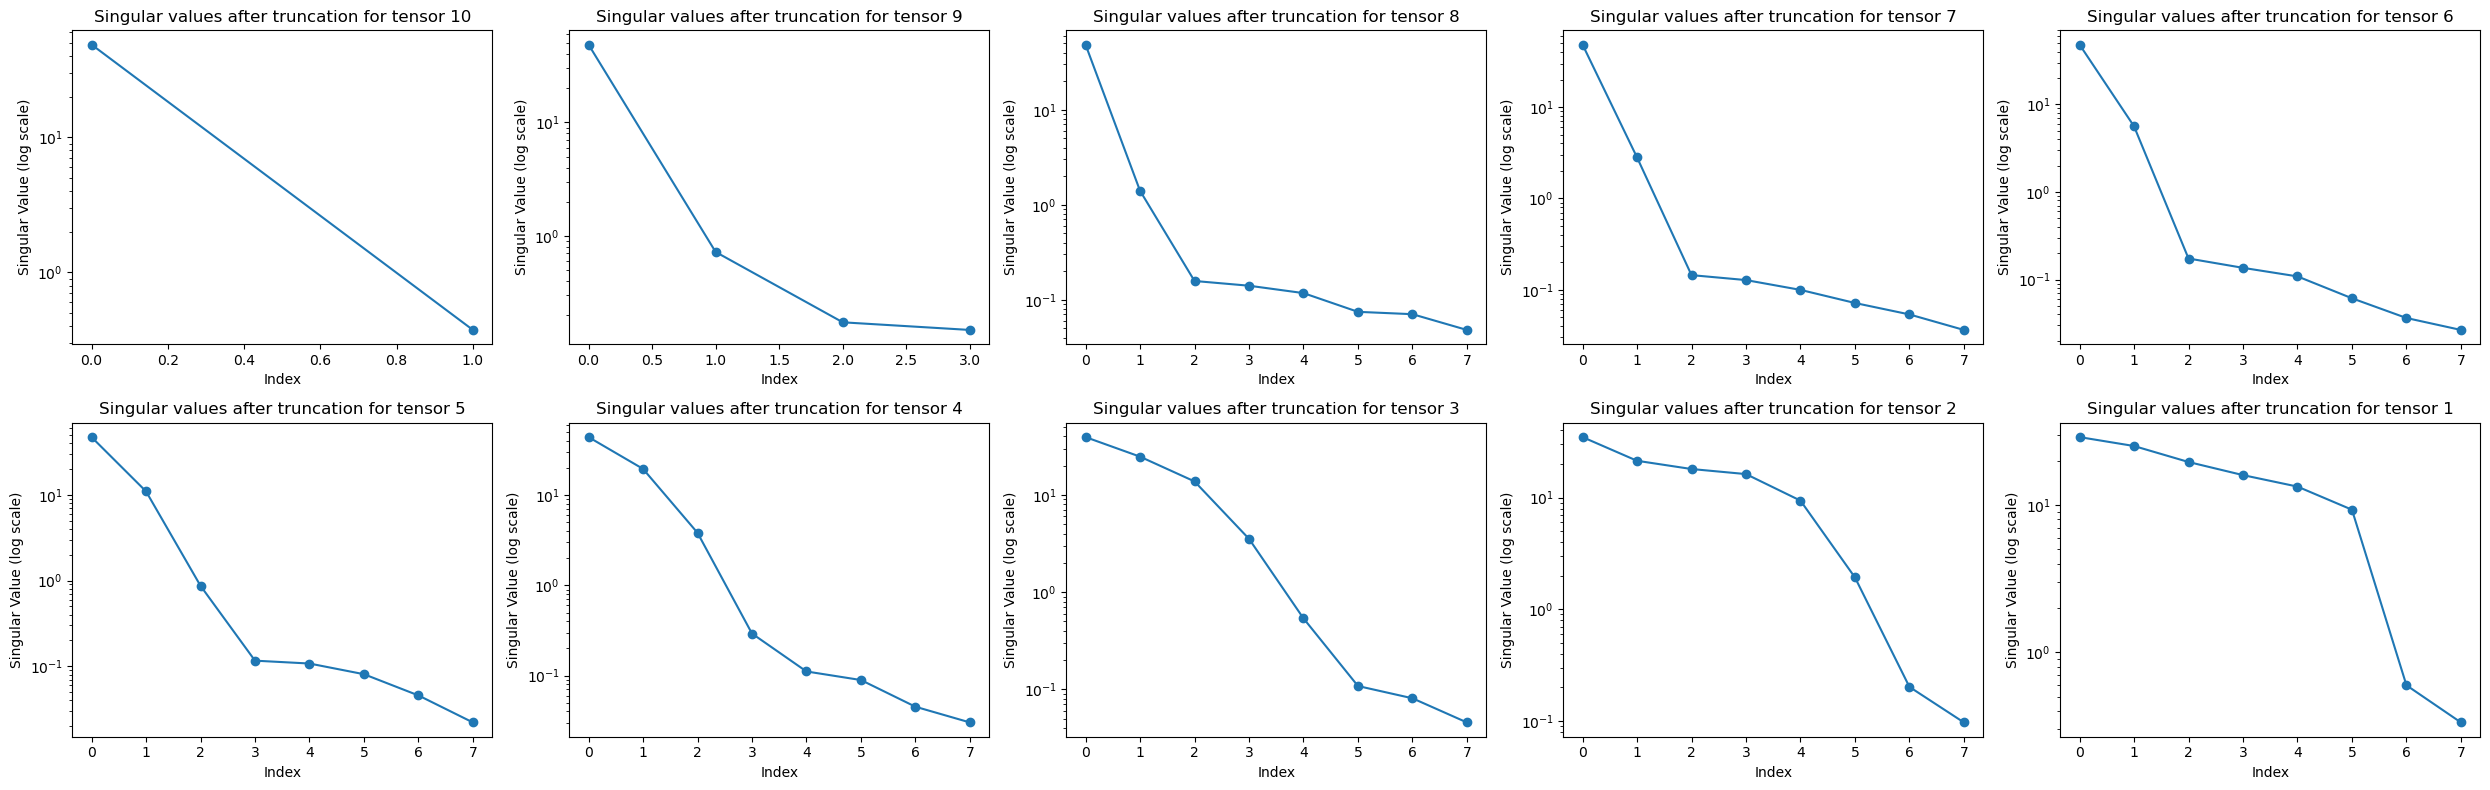

In [67]:
_, S_list = MPS.truncate(As_isometric.copy(), chi_max=chi, which='right_to_left')


fig, ax = plt.subplots(nrows=2, ncols = len(S_list)//2, figsize=(5*len(S_list)//2, 4*2))
ax = ax.flatten()
for i, S in enumerate(S_list):
    ax[i].plot(S[:8], 'o-')
    ax[i].set_xlabel('Index')
    ax[i].set_ylabel('Singular Value (log scale)')
    ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()

In [68]:
As_trunc, S_list = MPS.truncate(As_isometric.copy(), chi_max=7, which='right_to_left')

In [69]:
print(len(S_list))

10


In [70]:
for i, A in enumerate(As_trunc):
    print(f'tensor {i}: {A.shape}')

tensor 0: (11, 2, 7)
tensor 1: (7, 2, 7)
tensor 2: (7, 2, 7)
tensor 3: (7, 2, 7)
tensor 4: (7, 2, 7)
tensor 5: (7, 2, 7)
tensor 6: (7, 2, 7)
tensor 7: (7, 2, 7)
tensor 8: (7, 2, 4)
tensor 9: (4, 2, 2)
tensor 10: (2, 2, 1)


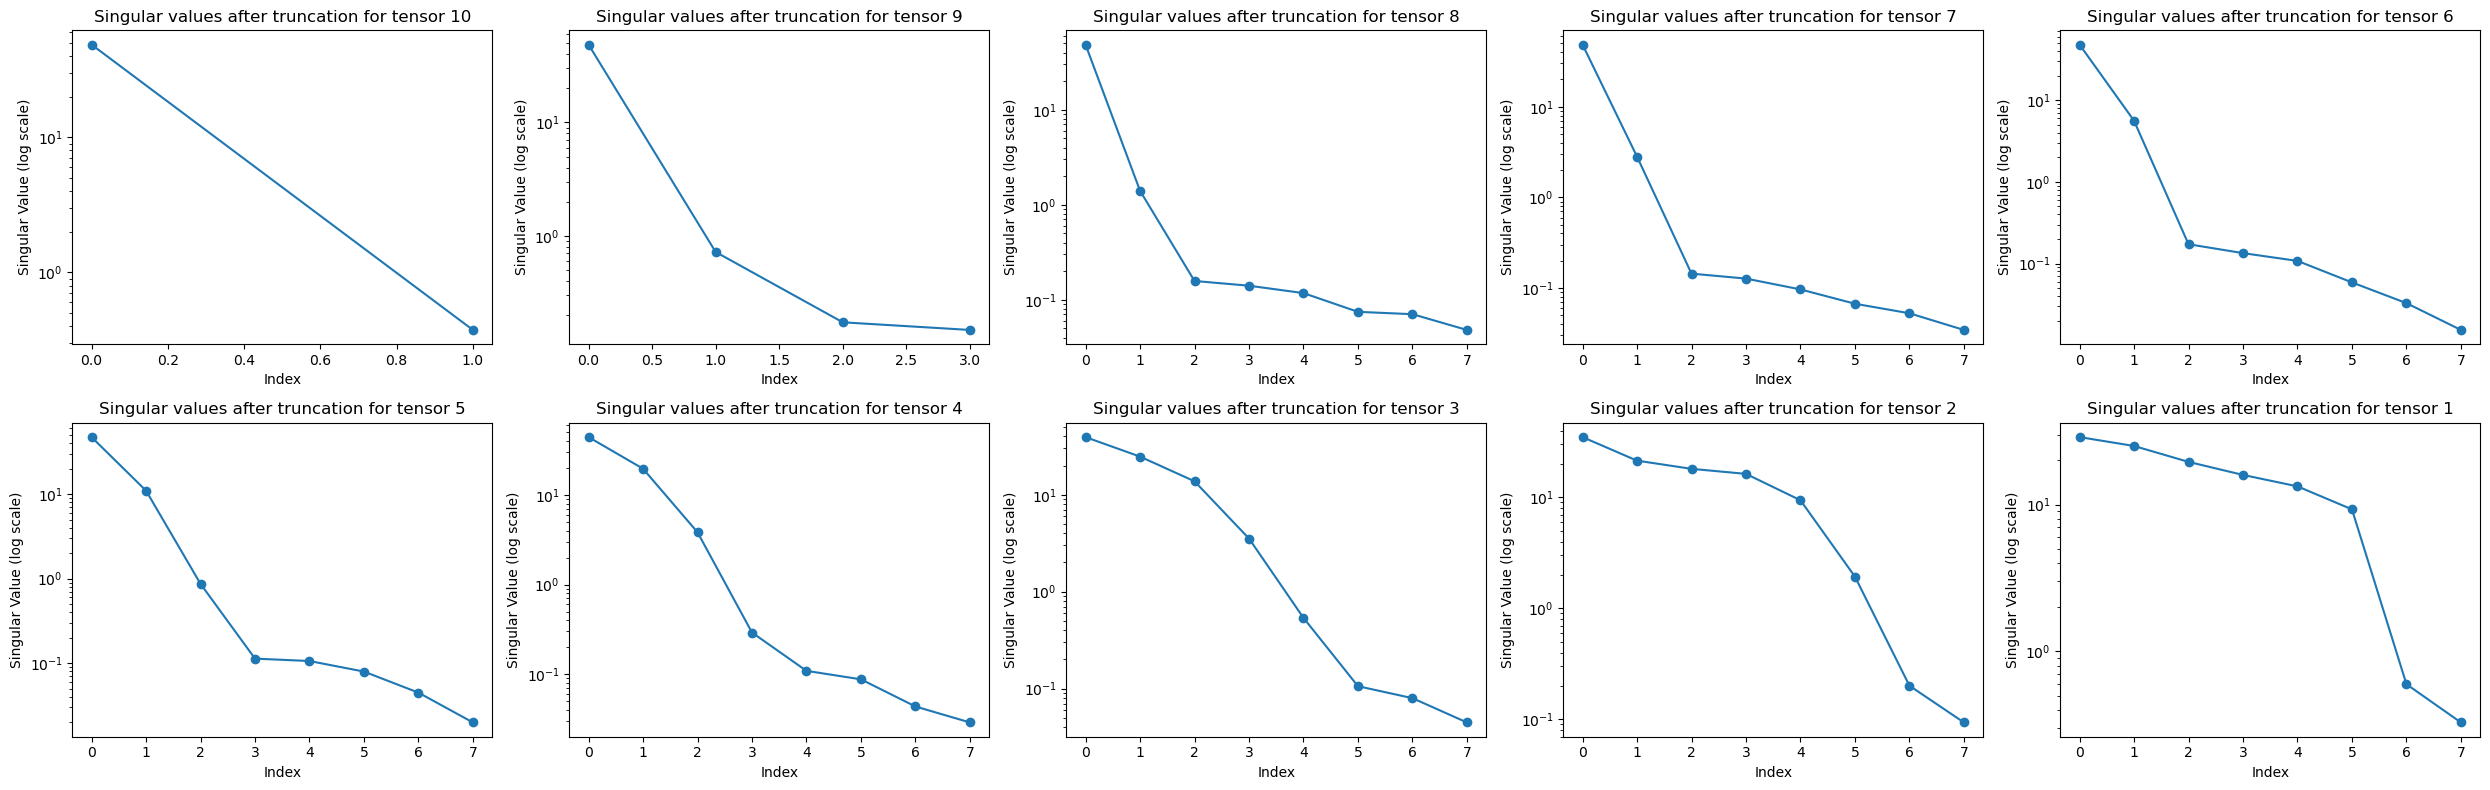

In [71]:
fig, ax = plt.subplots(nrows=2, ncols = len(S_list)//2, figsize=(5*len(S_list)//2, 4*2))
ax = ax.flatten()
for i, S in enumerate(S_list):
    ax[i].plot(S[:8], 'o-')
    ax[i].set_xlabel('Index')
    ax[i].set_ylabel('Singular Value (log scale)')
    ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()


# for S in S_list:
#     plt.plot(S, 'o-')
#     plt.yscale('log')
#     plt.xlabel('Index')
#     plt.ylabel('Singular Value (log scale)')
#     plt.title(f'Singular values after truncation')
#     plt.tight_layout()
#     plt.show()

In [72]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated): ", err_max, err_max_trunc)
print("2-norm error w.r.t. noisy function (tci vs truncated): ", err_2, err_2_trunc)

Max error w.r.t. noisy function (tci vs truncated):  0.06383942847689345 0.06311916336101313
2-norm error w.r.t. noisy function (tci vs truncated):  0.0647682803687244 0.0644118519314165


In [73]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated): ", err_max_theo, err_max_trunc_theo)
print("2-norm error w.r.t. theo function (tci vs truncated): ", err_2_theo, err_2_trunc_theo)

Max error w.r.t. theo function (tci vs truncated):  0.03892987194860091 0.03680140117035457
2-norm error w.r.t. theo function (tci vs truncated):  0.046114449417403225 0.04554593898392961


In [74]:
def plot_fig_chi(S_list, x_terms):
    fig, ax = plt.subplots(nrows=2, ncols = len(S_list)//2, figsize=(5*len(S_list)//2, 4*2))
    ax = ax.flatten()
    for i, S in enumerate(S_list):
        ax[i].plot(S[:x_terms], 'o-')
        ax[i].set_xlabel('Index')
        ax[i].set_ylabel('Singular Value (log scale)')
        ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
        ax[i].set_yscale('log')
    plt.tight_layout()
    plt.show()

In [75]:
for chi in [4,5,6,7]:
    As_trunc_chi, S_list = MPS.truncate(As_isometric.copy(), chi_max=chi, which='right_to_left')
    err_max_trunc_chi, err_2_trunc_chi = MPS.errors(As_trunc_chi, func_vals_noise)
    print(f"Max error w.r.t. noisy function (tci vs truncated with chi={chi}): ", err_max, err_max_trunc_chi)
    print(f"2-norm error w.r.t. noisy function (tci vs truncated with chi={chi}): ", err_2, err_2_trunc_chi)
    # plot_fig_chi(S_list, x_terms=8)


Max error w.r.t. noisy function (tci vs truncated with chi=4):  0.06383942847689345 0.4538510670666277
2-norm error w.r.t. noisy function (tci vs truncated with chi=4):  0.0647682803687244 0.3663223809060932
Max error w.r.t. noisy function (tci vs truncated with chi=5):  0.06383942847689345 0.1845855478037456
2-norm error w.r.t. noisy function (tci vs truncated with chi=5):  0.0647682803687244 0.2073826659120831
Max error w.r.t. noisy function (tci vs truncated with chi=6):  0.06383942847689345 0.06315717531961372
2-norm error w.r.t. noisy function (tci vs truncated with chi=6):  0.0647682803687244 0.06318955135070374
Max error w.r.t. noisy function (tci vs truncated with chi=7):  0.06383942847689345 0.06311916336101313
2-norm error w.r.t. noisy function (tci vs truncated with chi=7):  0.0647682803687244 0.0644118519314165


In [76]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
print("Errors w.r.t. theoretical function:")
for chi in [4,5,6,7]:
    As_trunc_chi, _ = MPS.truncate(As_isometric.copy(), chi_max=chi, which='right_to_left')
    err_max_trunc_chi, err_2_trunc_chi = MPS.errors(As_trunc_chi, func_vals_theo)
    print(f"Max error (tci chi = 8 vs truncated with chi={chi}): ", err_max_theo, err_max_trunc_chi)
    print(f"2-norm error (tci chi = 8 vs truncated with chi={chi}): ", err_2_theo, err_2_trunc_chi)
    # plot_fig_chi(S_list, x_terms=8)

Errors w.r.t. theoretical function:
Max error (tci chi = 8 vs truncated with chi=4):  0.03892987194860091 0.4550580112310542
2-norm error (tci chi = 8 vs truncated with chi=4):  0.046114449417403225 0.36403350738871854
Max error (tci chi = 8 vs truncated with chi=5):  0.03892987194860091 0.17250140409860806
2-norm error (tci chi = 8 vs truncated with chi=5):  0.046114449417403225 0.2023341057454956
Max error (tci chi = 8 vs truncated with chi=6):  0.03892987194860091 0.03804016608681442
2-norm error (tci chi = 8 vs truncated with chi=6):  0.046114449417403225 0.04370253752245801
Max error (tci chi = 8 vs truncated with chi=7):  0.03892987194860091 0.03680140117035457
2-norm error (tci chi = 8 vs truncated with chi=7):  0.046114449417403225 0.04554593898392961


Conclusion: not much improvement with respect to TCI without truncation (we find a small improvement when truncating chi but not significant), but we see that the error w.r.t. the theoretical function is much smaller than the error w.r.t. the noisy function, which suggests that the TCI in general works well to approximate the theoretical function.

## Other approach:
truncate each tensor by keeping only the singular values whose difference is above a certain threshold. In this way, we remove the singular values that are close to each other, which are more likely to be affected by noise. This is because if there is no noise singular values should decay exponentially, so if there are singular values that are close to each other, it means that the most significant contribution is given by noise which should give a quite constant contribution to the singular values.

In [77]:
As_trunc_alt, S_list_alt, chi_max_list = MPS.truncate_Gio(As_isometric.copy(),
                                                      threshold=0.3,
                                                      which='right_to_left')

In [78]:
for i, A in enumerate(chi_max_list):
    print(f'tensor {len(chi_max_list) - i}: chi_max = {A}')

tensor 10: chi_max = 3
tensor 9: chi_max = 3
tensor 8: chi_max = 3
tensor 7: chi_max = 3
tensor 6: chi_max = 3
tensor 5: chi_max = 4
tensor 4: chi_max = 4
tensor 3: chi_max = 6
tensor 2: chi_max = 7
tensor 1: chi_max = 7


In [79]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc_alt, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated): ", f"{err_max:.4f}", f"{err_max_trunc:.4f}")
print("2-norm error w.r.t. noisy function (tci vs truncated): ", f"{err_2:.4f}", f"{err_2_trunc:.4f}")

err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_alt, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci vs truncated): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. noisy function (tci vs truncated):  0.0638 0.0659
2-norm error w.r.t. noisy function (tci vs truncated):  0.0648 0.0644
Max error w.r.t. theo function (tci vs truncated):  0.0389 0.0367
2-norm error w.r.t. theo function (tci vs truncated):  0.0461 0.0453


## Now we do TCI with chi=16 and then truncate

In [80]:
func_noise = TCI.function(f_t_noise)
chi = 16

As, _, eval, err_2, err_max, func_interp_noise = TCI.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.055731802710867966
err_2:  0.052984168035299734

repeated evaluations:  51372
unique evaluations 1536
unique + repeated:  52908
total evaluations:  52908



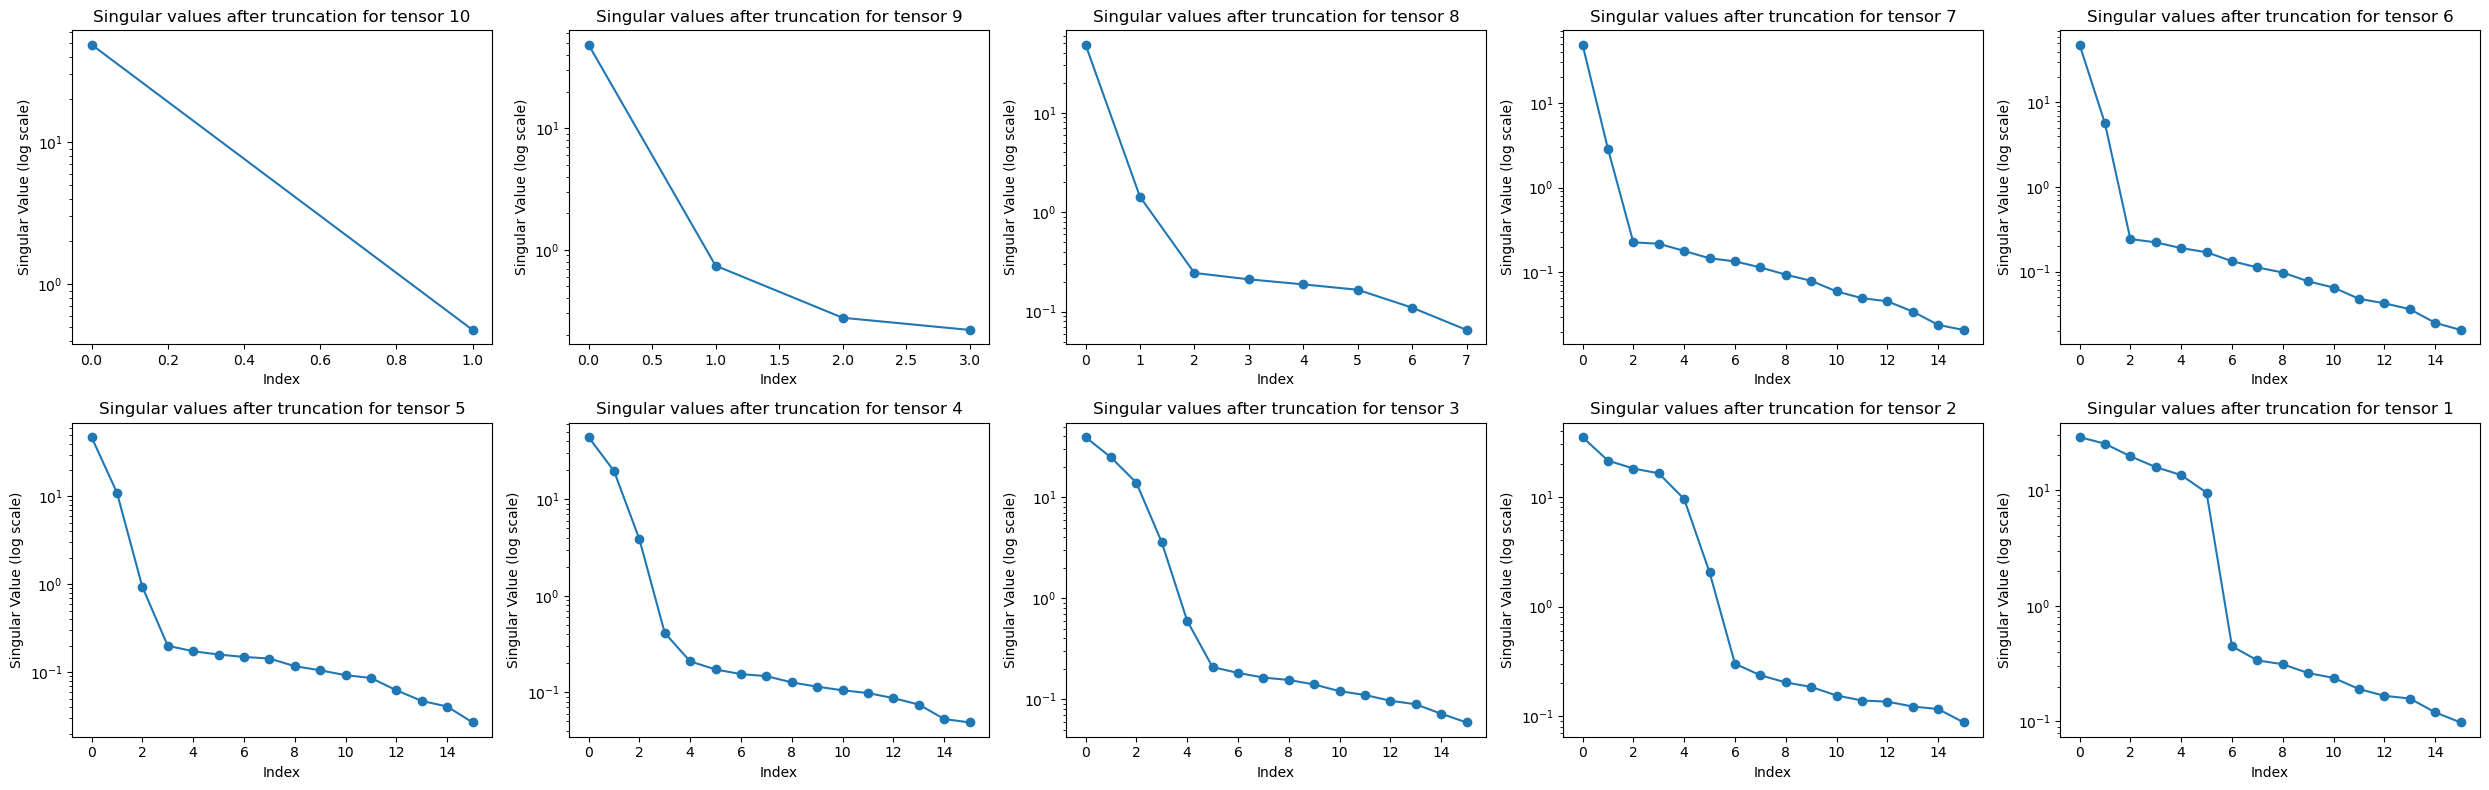

In [81]:
As_isometric = MPS.left_isometric(As.copy())

_, S_list = MPS.truncate(As_isometric.copy(), chi_max=chi, which='right_to_left')


fig, ax = plt.subplots(nrows=2, ncols = len(S_list)//2, figsize=(5*len(S_list)//2, 4*2))
ax = ax.flatten()
for i, S in enumerate(S_list):
    ax[i].plot(S[:chi], 'o-')
    ax[i].set_xlabel('Index')
    ax[i].set_ylabel('Singular Value (log scale)')
    ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()

### Truncation at chi = 8

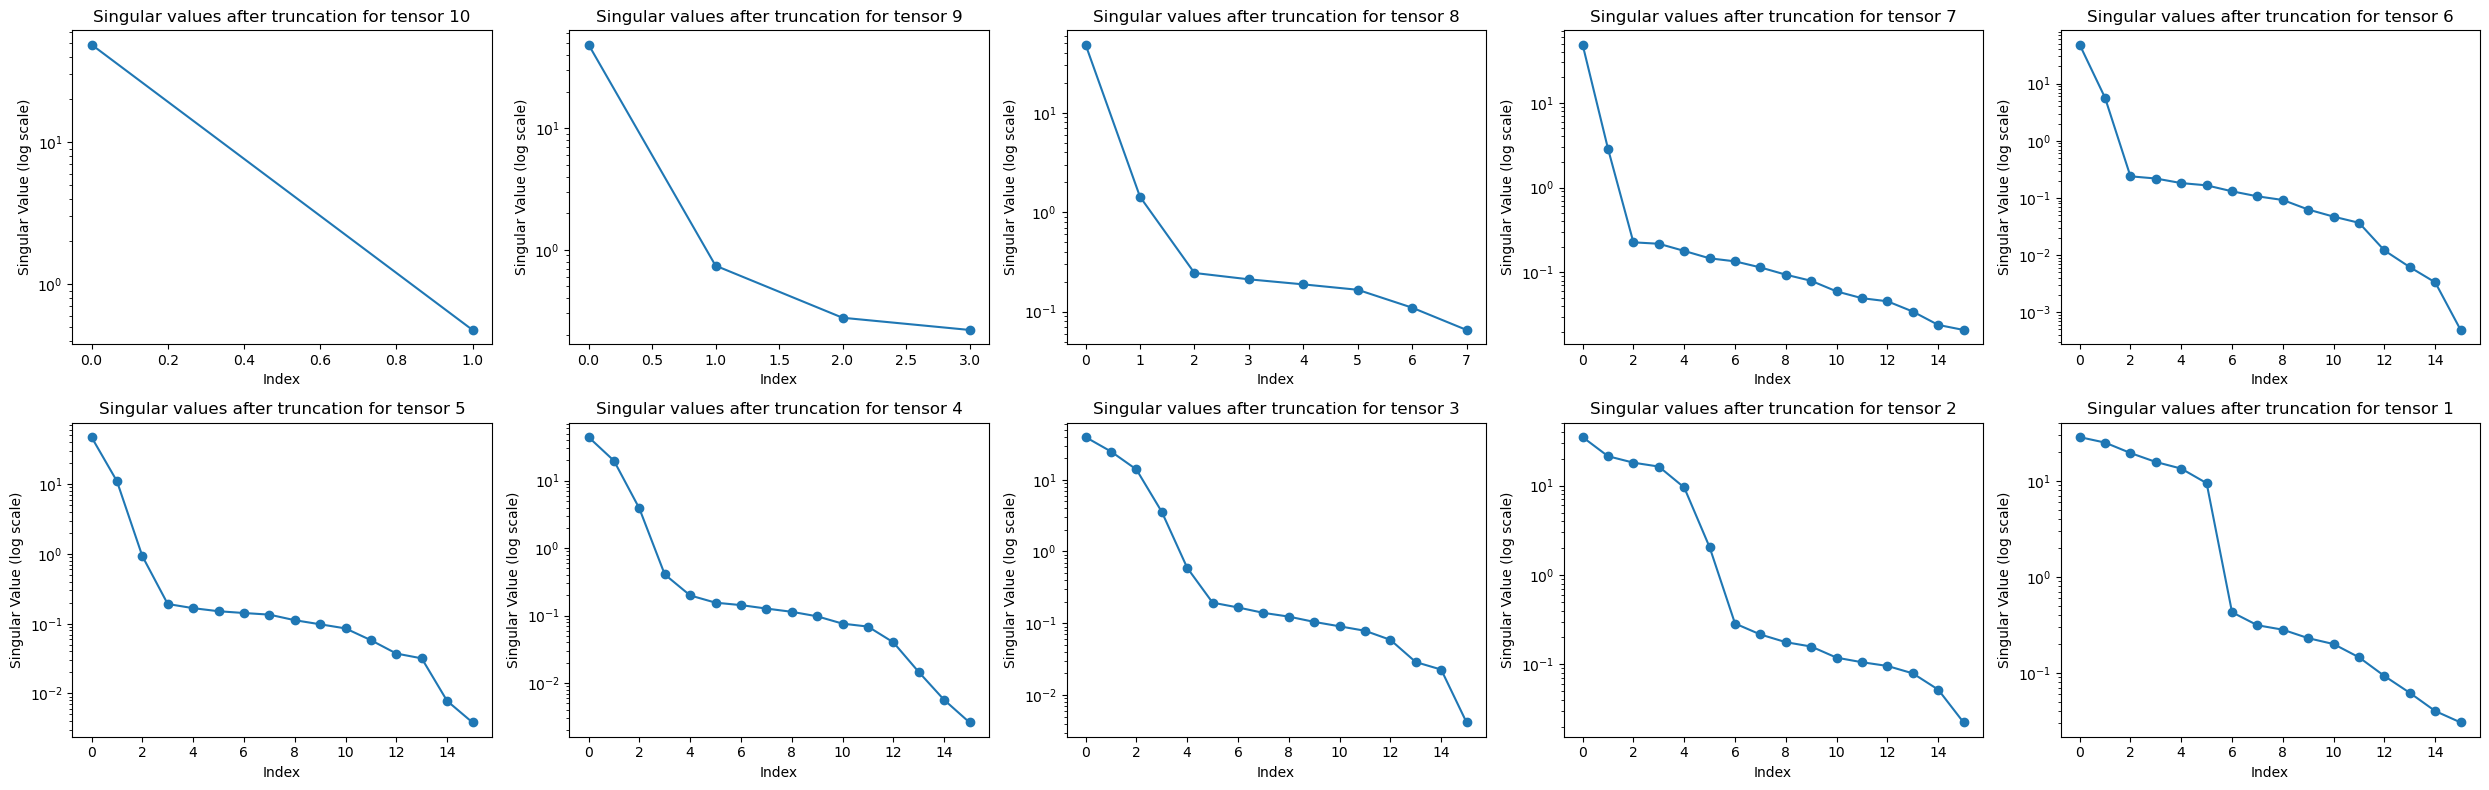

In [82]:
As_trunc, S_list_trunc = MPS.truncate(As_isometric.copy(), chi_max=8, which='right_to_left')

fig, ax = plt.subplots(nrows=2, ncols = len(S_list_trunc)//2, figsize=(5*len(S_list_trunc)//2, 4*2))
ax = ax.flatten()
for i, S in enumerate(S_list_trunc):
    ax[i].plot(S[:chi], 'o-')
    ax[i].set_xlabel('Index')
    ax[i].set_ylabel('Singular Value (log scale)')
    ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()


In [83]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc, func_vals_noise)
print("Max error w.r.t. noisy function (tci chi=16 vs truncated chi=8): ", err_max, err_max_trunc)
print("2-norm error w.r.t. noisy function (tci chi=16 vs truncated chi=8): ", err_2, err_2_trunc)

Max error w.r.t. noisy function (tci chi=16 vs truncated chi=8):  0.055731802710867966 0.053672849891231986
2-norm error w.r.t. noisy function (tci chi=16 vs truncated chi=8):  0.052984168035299734 0.05280140337963937


In [84]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc, func_vals_theo)
print("Max error w.r.t. theo function (tci chi=16 vs truncated chi=8): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci chi=16 vs truncated chi=8): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci chi=16 vs truncated chi=8):  0.0426 0.0264
2-norm error w.r.t. theo function (tci chi=16 vs truncated chi=8):  0.0300 0.0266


### Truncation at singular value threshold 1e-1

In [85]:
As_trunc_thresh, S_list_thresh = MPS.truncate(As_isometric.copy(), svd_min = 10**-1, chi_max=16, which='right_to_left')

In [86]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc_thresh, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated with svd_min 0.1): ", f"{err_max:.4f}", f"{err_max_trunc:.4f}")
print("2-norm error w.r.t. noisy function (tci vs truncated with svd_min 0.1): ", f"{err_2:.4f}", f"{err_2_trunc:.4f}")

Max error w.r.t. noisy function (tci vs truncated with svd_min 0.1):  0.0557 0.0553
2-norm error w.r.t. noisy function (tci vs truncated with svd_min 0.1):  0.0530 0.0533


In [87]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_thresh, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated with svd_min 0.1): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci vs truncated with svd_min 0.1): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci vs truncated with svd_min 0.1):  0.0426 0.0338
2-norm error w.r.t. theo function (tci vs truncated with svd_min 0.1):  0.0300 0.0291


### Alternative truncation method based on singular value differences

In [88]:
As_trunc_alt, S_list_alt, chi_max_list = MPS.truncate_Gio(As_isometric.copy(),
                                                      threshold=0.2,
                                                      which='right_to_left')

In [89]:
for i, A in enumerate(chi_max_list):
    print(f'tensor {len(chi_max_list) - i}: chi_max = {A}')

tensor 10: chi_max = 3
tensor 9: chi_max = 3
tensor 8: chi_max = 3
tensor 7: chi_max = 3
tensor 6: chi_max = 3
tensor 5: chi_max = 4
tensor 4: chi_max = 5
tensor 3: chi_max = 6
tensor 2: chi_max = 7
tensor 1: chi_max = 7


In [90]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc_alt, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated with threshold 0.2): ", f"{err_max:.4f}", f"{err_max_trunc:.4f}")
print("2-norm error w.r.t. noisy function (tci vs truncated with threshold 0.2): ", f"{err_2:.4f}", f"{err_2_trunc:.4f}")

Max error w.r.t. noisy function (tci vs truncated with threshold 0.2):  0.0557 0.0530
2-norm error w.r.t. noisy function (tci vs truncated with threshold 0.2):  0.0530 0.0526


In [91]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_alt, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated with threshold 0.2): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci vs truncated with threshold 0.2): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci vs truncated with threshold 0.2):  0.0426 0.0228
2-norm error w.r.t. theo function (tci vs truncated with threshold 0.2):  0.0300 0.0254


### Now we do a plot of error w.r.t. the theoretical function for this last truncation method for different values of the threshold:

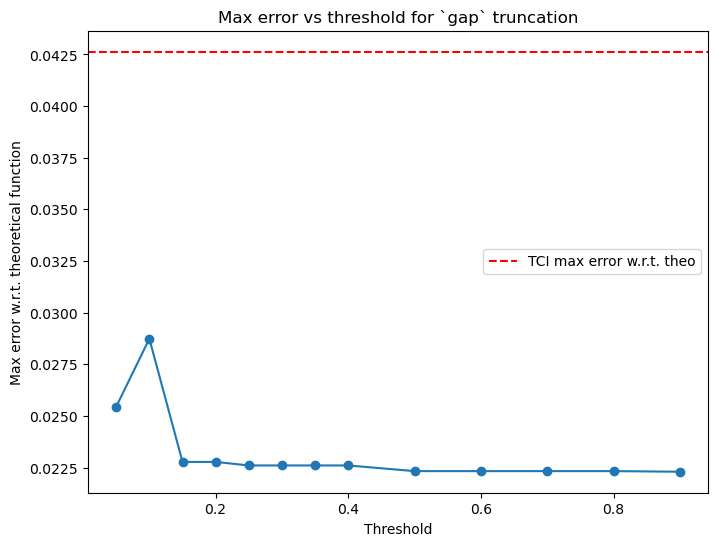

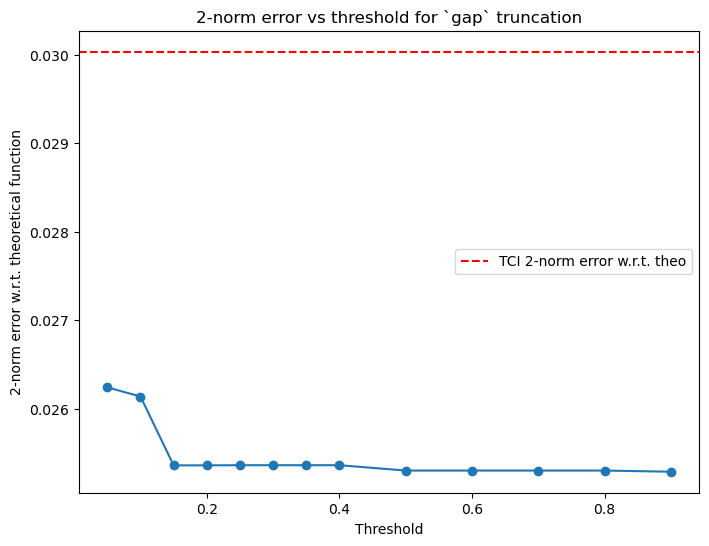

In [92]:
err_max_list = []
err_2_list = []
threshold_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in threshold_values:
    As_trunc_alt,_, _ = MPS.truncate_Gio(As_isometric.copy(),
                                                          threshold=threshold,
                                                          which='right_to_left')
    err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_alt, func_vals_theo)
    err_max_list.append(err_max_trunc_theo)
    err_2_list.append(err_2_trunc_theo)

plt.figure(figsize=(8,6))
plt.plot(threshold_values, err_max_list, 'o-')
plt.axhline(y=err_max_theo, color='r', linestyle='--', label='TCI max error w.r.t. theo')
plt.xlabel('Threshold')
plt.ylabel('Max error w.r.t. theoretical function')
plt.title('Max error vs threshold for `gap` truncation')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(threshold_values, err_2_list, 'o-')
plt.axhline(y=err_2_theo, color='r', linestyle='--', label='TCI 2-norm error w.r.t. theo')
plt.xlabel('Threshold')
plt.ylabel('2-norm error w.r.t. theoretical function')
plt.title('2-norm error vs threshold for `gap` truncation')
plt.legend()
plt.show()


## Now we repeat the procedure but with TCI with chi=11, and then truncate

In [93]:
func_noise = TCI.function(f_t_noise)
chi = 11

As, _, eval, err_2, err_max, func_interp_noise = TCI.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.057252049977983915
err_2:  0.05860172572982133

repeated evaluations:  20182
unique evaluations 946
unique + repeated:  21128
total evaluations:  21128



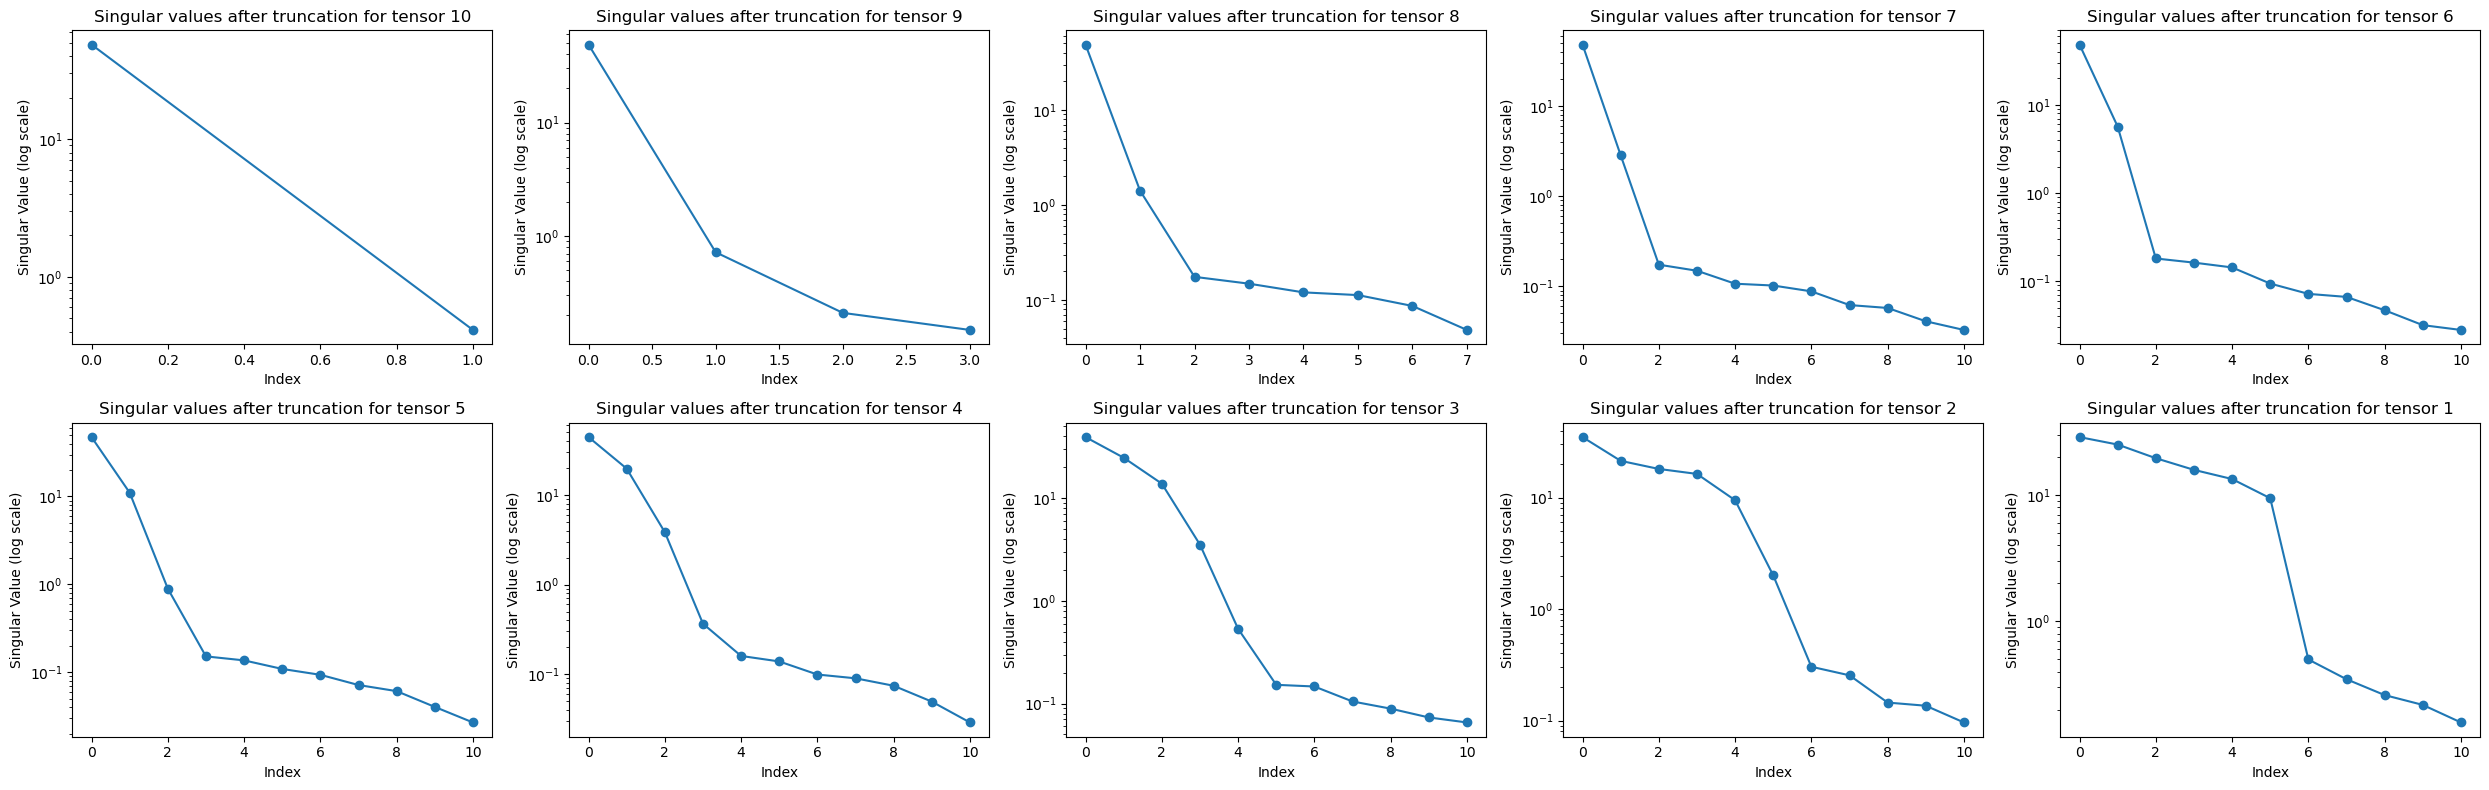

In [94]:
As_isometric = MPS.left_isometric(As.copy())

_, S_list = MPS.truncate(As_isometric.copy(), chi_max=chi, which='right_to_left')


fig, ax = plt.subplots(nrows=2, ncols = len(S_list)//2, figsize=(5*len(S_list)//2, 4*2))
ax = ax.flatten()
for i, S in enumerate(S_list):
    ax[i].plot(S[:chi], 'o-')
    ax[i].set_xlabel('Index')
    ax[i].set_ylabel('Singular Value (log scale)')
    ax[i].set_title(f'Singular values after truncation for tensor {len(S_list) - i}')
    ax[i].set_yscale('log')
plt.tight_layout()
plt.show()

### Truncation at chi = 7

In [95]:
As_trunc, S_list_trunc = MPS.truncate(As_isometric.copy(), chi_max=7, which='right_to_left')


In [96]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc, func_vals_noise)
print("Max error w.r.t. noisy function (tci chi=16 vs truncated chi=8): ", err_max, err_max_trunc)
print("2-norm error w.r.t. noisy function (tci chi=16 vs truncated chi=8): ", err_2, err_2_trunc)

Max error w.r.t. noisy function (tci chi=16 vs truncated chi=8):  0.057252049977983915 0.05723195163268085
2-norm error w.r.t. noisy function (tci chi=16 vs truncated chi=8):  0.05860172572982133 0.05785997407503068


In [97]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc, func_vals_theo)
print("Max error w.r.t. theo function (tci chi=16 vs truncated chi=8): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci chi=16 vs truncated chi=8): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci chi=16 vs truncated chi=8):  0.0371 0.0288
2-norm error w.r.t. theo function (tci chi=16 vs truncated chi=8):  0.0374 0.0354


### Truncation at singular value threshold 1e-1

In [98]:
As_trunc_thresh, S_list_thresh = MPS.truncate(As_isometric.copy(), svd_min = 10**-1, chi_max=16, which='right_to_left')

In [99]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc_thresh, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated with svd_min 0.1): ", f"{err_max:.4f}", f"{err_max_trunc:.4f}")
print("2-norm error w.r.t. noisy function (tci vs truncated with svd_min 0.1): ", f"{err_2:.4f}", f"{err_2_trunc:.4f}")

Max error w.r.t. noisy function (tci vs truncated with svd_min 0.1):  0.0573 0.0563
2-norm error w.r.t. noisy function (tci vs truncated with svd_min 0.1):  0.0586 0.0587


In [100]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_thresh, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated with svd_min 0.1): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci vs truncated with svd_min 0.1): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci vs truncated with svd_min 0.1):  0.0371 0.0349
2-norm error w.r.t. theo function (tci vs truncated with svd_min 0.1):  0.0374 0.0370


### Alternative truncation method based on singular value differences

In [101]:
As_trunc_alt, S_list_alt, chi_max_list = MPS.truncate_Gio(As_isometric.copy(),
                                                      threshold=0.2,
                                                      which='right_to_left')

In [102]:
for i, A in enumerate(chi_max_list):
    print(f'tensor {len(chi_max_list) - i}: chi_max = {A}')

tensor 10: chi_max = 3
tensor 9: chi_max = 3
tensor 8: chi_max = 3
tensor 7: chi_max = 3
tensor 6: chi_max = 3
tensor 5: chi_max = 4
tensor 4: chi_max = 5
tensor 3: chi_max = 6
tensor 2: chi_max = 7
tensor 1: chi_max = 7


In [103]:
err_max_trunc, err_2_trunc = MPS.errors(As_trunc_alt, func_vals_noise)
print("Max error w.r.t. noisy function (tci vs truncated with threshold 0.2): ", f"{err_max:.4f}", f"{err_max_trunc:.4f}")
print("2-norm error w.r.t. noisy function (tci vs truncated with threshold 0.2): ", f"{err_2:.4f}", f"{err_2_trunc:.4f}")

Max error w.r.t. noisy function (tci vs truncated with threshold 0.2):  0.0573 0.0577
2-norm error w.r.t. noisy function (tci vs truncated with threshold 0.2):  0.0586 0.0580


In [104]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
err_max_trunc_theo, err_2_trunc_theo = MPS.errors(As_trunc_alt, func_vals_theo)
print("Max error w.r.t. theo function (tci vs truncated with threshold 0.2): ", f"{err_max_theo:.4f}", f"{err_max_trunc_theo:.4f}")
print("2-norm error w.r.t. theo function (tci vs truncated with threshold 0.2): ", f"{err_2_theo:.4f}", f"{err_2_trunc_theo:.4f}")

Max error w.r.t. theo function (tci vs truncated with threshold 0.2):  0.0371 0.0286
2-norm error w.r.t. theo function (tci vs truncated with threshold 0.2):  0.0374 0.0354


/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


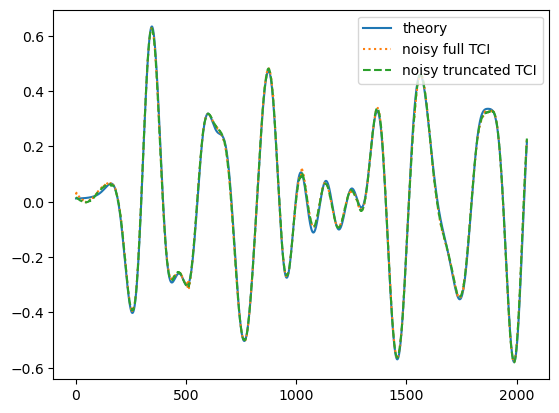

In [ ]:
plt.plot(np.arange(N), func_vals_theo[:,0], '-', label = 'theory')
plt.plot(np.arange(N), func_interp_noise[:,0], ':', label = 'noisy full TCI')
plt.plot(np.arange(N), MPS.interpolate_func(As_trunc_alt)[:,0], '--', label = 'noisy truncated TCI')

# plt.xlim(1000,1200)
# plt.ylim(-0.2,0.2)
plt.legend()

/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


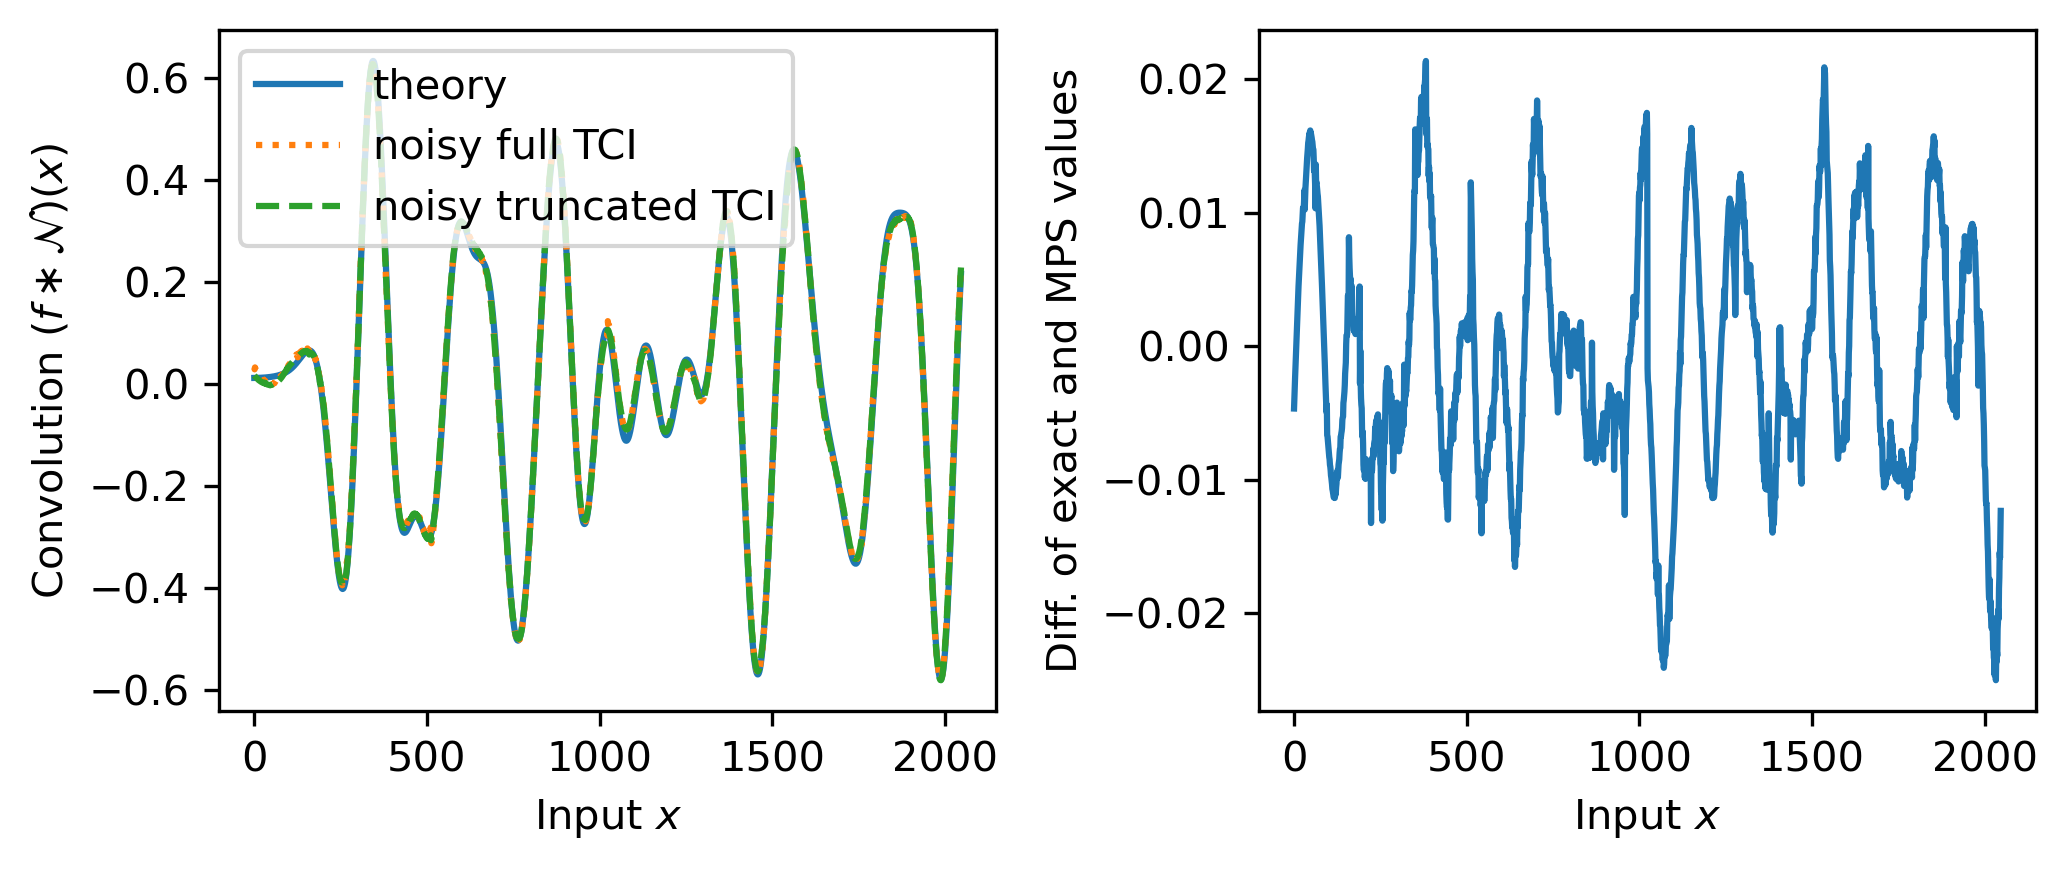

In [108]:
# Scegli l'indice spaziale/temporale da visualizzare nel plot
idx_to_plot = 0

xs = np.arange(N)

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(np.arange(N), func_vals_theo[:,0], '-', label = 'theory')
axs[0].plot(np.arange(N), func_interp_noise[:,0], ':', label = 'noisy full TCI')
axs[0].plot(np.arange(N), MPS.interpolate_func(As_trunc_alt)[:,0], '--', label = 'noisy truncated TCI')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].legend()

axs[1].plot(xs, func_vals_theo[:,0] - MPS.interpolate_func(As_trunc_alt)[:,0], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

plt.tight_layout()
plt.show()

In [107]:
#probably it does not make sense to add threshold_big to new method, go back to previous way!